# ML for Social Good — Ensemble Challenge
### Mission Earth: Predicting City-Level Air Quality Risk Category (AQI Bucket) from Pollutant Sensor Readings

**Course:** MCA 521-4 Machine Learning | **Assessment:** CIA-3 (25 Marks)

**Name:** ``   **Register No.:** ``
`





---
## Q1. Real-World Impact Framing  *(CO5 / L2 — 5 Marks)*

**Mission selected:** Mission Earth — Environment

**Problem statement.** Air pollution is one of India's largest public-health burdens. Cities publish
raw pollutant sensor readings (PM2.5, PM10, NO2, SO2, CO, O3, etc.) but many residents, schools, and
local clinics cannot interpret raw concentration numbers in real time. This project builds a model
that converts same-day raw pollutant sensor readings into the **standard CPCB AQI risk category**
(Good → Severe), so an automated early-warning/advisory system can flag high-risk days without
waiting for a human analyst to manually compute the composite AQI.

**Intended beneficiaries.**
- City/state pollution-control boards and municipal health departments issuing public advisories.
- Schools, hospitals, and outdoor-worker organisations that need same-day risk categories to decide
  on precautions (e.g., cancel outdoor sports, advise masks for construction workers).
- Citizens with respiratory/cardiac conditions who rely on simplified risk categories rather than raw
  pollutant numbers.
- Smaller/under-monitored towns that could reuse a trained model as a low-cost sanity-check layer
  while their own monitoring infrastructure is still being built out.

**Prediction target.** `AQI_Bucket` — a 6-class categorical label (**Good, Satisfactory, Moderate,
Poor, Very Poor, Severe**) assigned by CPCB from a day's pollutant readings for a given city.

**Unit of analysis.** One row = one (city, calendar day) observation — a *city-day*.

**Measurable impact.** A model with high recall on the "Poor / Very Poor / Severe" classes lets an
advisory system flag dangerous days automatically and earlier in the pipeline (as soon as sensor
readings land), instead of waiting for manual AQI computation and publication, which in practice can
lag by hours. Measurable success = high **macro-F1** and **recall on high-risk classes** (since
missing a genuine "Severe" day is the costliest error — see Q4 for the false-negative discussion),
while still keeping overall accuracy respectable.

**Why Machine Learning is suitable.** The mapping from 8+ correlated pollutant concentrations to a
6-class ordinal risk bucket is non-linear and interacts with seasonality and city-specific baselines
(e.g., the same PM2.5 reading can mean different relative risk in Delhi's winter vs. a coastal city's
monsoon). A single hand-written threshold rule struggles here; ensemble tree methods can learn these
interactions directly from historical data, and are fast enough to score a new sensor reading in
milliseconds — suitable for a near-real-time advisory pipeline.

**Dataset source.** *Air Quality Data in India (2015–2020)*, day-level records for 26 Indian cities,
originally compiled from the **Central Pollution Control Board (CPCB), Government of India** and
published on Kaggle by Rohan Rao: `https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india`
(file used: `city_day.csv`). **Important — read before you submit:** this sandbox environment does not
have Kaggle network access, so the exact same file was retrieved from a public GitHub mirror of that
Kaggle dataset for development here. **You must re-download `city_day.csv` directly from the Kaggle
link above** (free Kaggle account, no cost) before you submit, cite the Kaggle page as shown above,
and drop it into the `data/` folder — the code does not change at all. This is flagged explicitly in
the README as well so nothing gets lost.

**Responsible-use limitations (see also Q4 Ethics).** Monitoring stations are concentrated in large
metros — 26 cities only, several under-represented with few station-days — so predictions for
un-monitored towns/rural areas are extrapolations, not measurements, and should not be used as a
substitute for installing local sensors. The model is descriptive of 2015–2019 pollution patterns and
will drift as emission sources, vehicle fleets, and regulations change; it must be periodically
retrained, not deployed once and forgotten.


In [2]:
# Q1 support: load the raw file and show its shape / first rows so the framing above
# is grounded in the actual data, not just described in prose.
import pandas as pd

RAW_PATH = "city_day.csv"   # <- put the Kaggle-downloaded city_day.csv here
raw = pd.read_csv(RAW_PATH)
print("Raw shape:", raw.shape)
print("Cities covered:", raw['City'].nunique())
print("Date range:", raw['Date'].min(), "to", raw['Date'].max())
raw.head()


Raw shape: (29531, 16)
Cities covered: 26
Date range: 2015-01-01 to 2020-07-01


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


---
## Q2. Data Wrangling and Feature Engineering  *(CO2 / L3 — 6 Marks)*

### 2.1 Missing-value audit


In [3]:
missing_pct = (raw.isna().mean() * 100).round(1).sort_values(ascending=False)
print("Missing value % by column:\n")
print(missing_pct)


Missing value % by column:

Xylene        61.3
PM10          37.7
NH3           35.0
Toluene       27.2
Benzene       19.0
AQI           15.9
AQI_Bucket    15.9
PM2.5         15.6
NOx           14.2
O3            13.6
SO2           13.1
NO2           12.1
NO            12.1
CO             7.0
Date           0.0
City           0.0
dtype: float64


**Decisions on missing data (justified):**
- `AQI` / `AQI_Bucket` are missing together for ~15.9% of rows — this means the ground-truth label
  itself is absent. These rows **cannot be used for supervised training or evaluation** and are
  dropped (they could optionally be used later for *unsupervised* pattern-mining, but that's outside
  this brief).
- `Xylene` is missing for **61.3%** of rows — too sparse to impute defensibly without inventing most
  of the signal, so the column is **dropped** entirely.
- The remaining pollutant columns (PM10, NH3, Toluene, etc.) have moderate missingness (7%–38%).
  These are **not dropped**, because they carry real predictive signal. Instead:
  1. A **missing-value indicator flag** (`PM10_missing`, `NH3_missing`, `Toluene_missing`) is added
     for the three worst-affected columns, since *whether* a sensor was reporting can itself be
     informative (e.g., sensor downtime often correlates with maintenance backlogs in specific
     cities/years).
  2. Actual value imputation is done with **median imputation**, and — critically — the median is
     **fit only on the training split** (inside a `Pipeline`/`ColumnTransformer`) and then applied to
     validation/test, so no information leaks from val/test into training.

### 2.2 Duplicates and invalid data


In [4]:
print("Exact duplicate rows:", raw.duplicated().sum())

num_cols_check = raw.select_dtypes(include='number').columns
neg_counts = (raw[num_cols_check] < 0).sum()
print("\nNegative-value counts per numeric column (pollutant concentrations physically cannot be negative):")
print(neg_counts)


Exact duplicate rows: 0

Negative-value counts per numeric column (pollutant concentrations physically cannot be negative):
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
AQI        0
dtype: int64


No exact duplicate rows and no physically-invalid negative pollutant concentrations were found, so
no rows needed to be dropped on those grounds.

### 2.3 Data types
`Date` arrives as a string (`DD-MM-YYYY`) and is parsed to `datetime64`. `City` and `AQI_Bucket` are
categorical strings; all pollutant columns are already numeric (`float64`).

### 2.4 Outliers
Pollutant sensor readings have a long right tail (pollution spikes during festivals like Diwali,
stubble-burning season, etc.). These spikes are *real* extreme values, not sensor errors, so they are
not deleted — but a small number of implausibly extreme single-sensor readings can still destabilise
distance/gradient-based learners. An **IQR-capping transformer** (factor = 3×IQR, wider than the
standard 1.5× so genuine pollution spikes are preserved and only the most extreme outliers are
clipped) is fit **on the training split only** and reused on validation/test — again leakage-safe.

### 2.5 Categorical encoding & numerical scaling
- `City` (26 levels) and the engineered `Season` (4 levels) are **one-hot encoded**
  (`handle_unknown='ignore'` so an unseen city at inference time doesn't crash the pipeline).
- All numeric pollutant/date features are **standard-scaled** (zero mean, unit variance) — required
  for the Logistic-Regression baseline to converge sensibly and to keep coefficients comparable;
  harmless for the tree-based ensembles.

### 2.6 Class imbalance


AQI_Bucket
Moderate        8829
Satisfactory    8224
NaN             4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


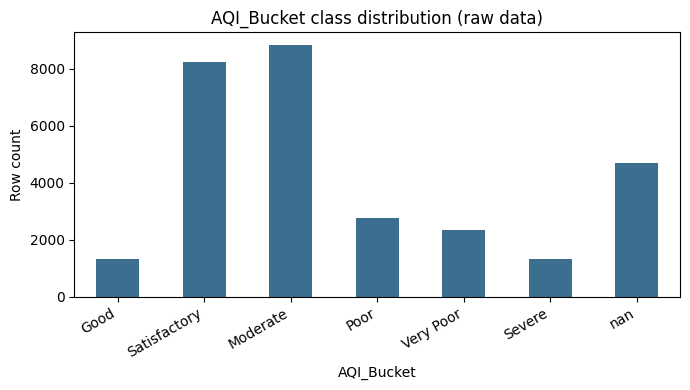

In [6]:
bucket_counts = raw['AQI_Bucket'].value_counts(dropna=False)
print(bucket_counts)
ax = bucket_counts.reindex(['Good','Satisfactory','Moderate','Poor','Very Poor','Severe', float('nan')]) \
        .rename(index={float('nan'): 'Missing label\n(dropped)'}).plot(kind='bar', figsize=(7,4), color='#3B6E8F')
ax.set_ylabel("Row count"); ax.set_title("AQI_Bucket class distribution (raw data)")
import matplotlib.pyplot as plt
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=140)
plt.show()


The target is clearly imbalanced: `Moderate` and `Satisfactory` dominate (~65% of labelled rows
combined) while `Good` and `Severe` are each only ~5–6%. Because `Severe` is simultaneously the
rarest class **and** the one whose false negatives are most costly (Q4), imbalance is handled with
**`class_weight='balanced'`** for Logistic Regression and Random Forest, and **inverse-frequency
`sample_weight`** for XGBoost (which has no native `class_weight` argument) — rather than synthetic
oversampling (e.g. SMOTE). SMOTE was considered but deliberately avoided here: interpolating synthetic
points between real pollutant sensor readings risks inventing physically implausible
pollutant-concentration combinations for a domain with hard chemistry/physics constraints, which is
hard to defend to a public-health stakeholder. Class weighting keeps every training row genuine.

### 2.7 Exploratory Data Analysis


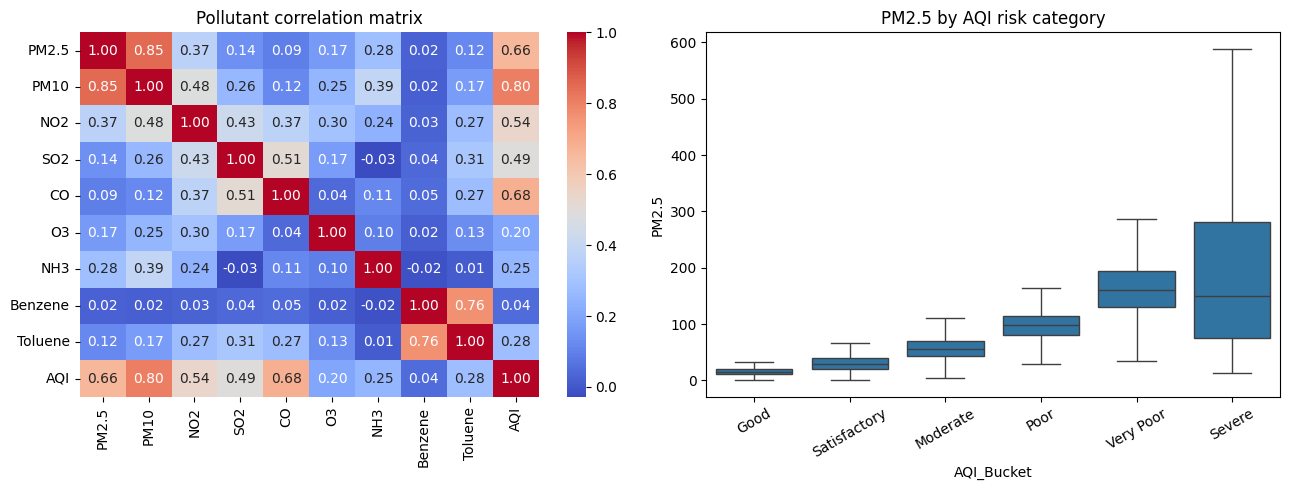

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = raw.dropna(subset=['AQI_Bucket']).copy()
df_eda['Date'] = pd.to_datetime(df_eda['Date'], format="mixed")
df_eda['Month'] = df_eda['Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(13,5))
corr = df_eda[['PM2.5','PM10','NO2','SO2','CO','O3','NH3','Benzene','Toluene','AQI']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title("Pollutant correlation matrix")

order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
sns.boxplot(data=df_eda, x='AQI_Bucket', y='PM2.5', order=order, ax=axes[1], showfliers=False)
axes[1].set_title("PM2.5 by AQI risk category")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("figures/eda_correlation_and_pm25.png", dpi=140)
plt.show()

**EDA takeaways:** PM2.5 and PM10 are highly correlated with each other and with the overall AQI
(as expected — particulate matter drives most of India's AQI). PM2.5 rises monotonically with AQI
risk category, confirming it is a strong, sensible predictor rather than a spurious correlation, which
supports its dominance in the SHAP explanations in Q4.

### 2.8 Feature engineering (recap)
`Month`, `Year`, `DayOfWeek`, and a derived `Season` (Winter/Summer/Monsoon/Post-Monsoon — matching
India's actual seasonal pollution cycle, not the calendar-default four seasons) are engineered from
`Date` to let the model learn seasonal pollution baselines (e.g. Delhi's winter smog) without leaking
the future, since the calendar date of a new reading is always known at prediction time.

### 2.9 Train / Validation / Test strategy (leakage-safe)
A **time-based split, done independently within each city**: for every city, the earliest 70% of its
dates → train, next 15% → validation, final 15% → test. This is deliberately **not** a random shuffle
split, because a random split would let the model "see" pollutant patterns from days chronologically
close to (sometimes literally the week after) a test-set day, which is unrealistic — in real
deployment the model only ever has the past to learn from. Splitting **within each city** (rather than
holding out entire cities) keeps every city represented in training, which matches the deployment
goal of serving all 26 currently-monitored cities.


In [11]:
raw['Date'] = pd.to_datetime(raw['Date'], format="mixed")
df = raw.dropna(subset=['AQI_Bucket']).copy()
df = df.drop(columns=['Xylene'])

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.dayofweek

def season_of(m):
    if m in [12, 1, 2]:
        return 'Winter'
    if m in [3, 4, 5]:
        return 'Summer'
    if m in [6, 7, 8, 9]:
        return 'Monsoon'
    return 'PostMonsoon'

df['Season'] = df['Month'].apply(season_of)

for c in ['PM10', 'NH3', 'Toluene']:
    df[c + '_missing'] = df[c].isna().astype(int)

NUM_COLS = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene',
            'Month','Year','DayOfWeek']
BIN_COLS = ['PM10_missing','NH3_missing','Toluene_missing']
CAT_COLS = ['City','Season']
FEATURE_COLS = NUM_COLS + BIN_COLS + CAT_COLS
TARGET = 'AQI_Bucket'

df = df.sort_values(['City', 'Date'])
train_idx, val_idx, test_idx = [], [], []
for city, g in df.groupby('City'):
    n = len(g)
    i1, i2 = int(n * 0.70), int(n * 0.85)
    train_idx += list(g.index[:i1]); val_idx += list(g.index[i1:i2]); test_idx += list(g.index[i2:])

train_df, val_df, test_df = df.loc[train_idx], df.loc[val_idx], df.loc[test_idx]
print("Train / Val / Test rows:", len(train_df), len(val_df), len(test_df))
print("\nClass balance in TRAIN split:")
print(train_df[TARGET].value_counts(normalize=True).round(3))


Train / Val / Test rows: 17383 3730 3737

Class balance in TRAIN split:
AQI_Bucket
Moderate        0.356
Satisfactory    0.311
Poor            0.119
Very Poor       0.108
Severe          0.062
Good            0.044
Name: proportion, dtype: float64


In [12]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

class IQRCapper(BaseEstimator, TransformerMixin):
    """Caps numeric outliers using IQR bounds learned ONLY on the data passed to
    .fit() (i.e. the training split) -- prevents test/val leakage into the cap bounds."""
    def __init__(self, cols, factor=3.0):
        self.cols = cols; self.factor = factor
    def fit(self, X, y=None):
        self.bounds_ = {}
        for c in self.cols:
            q1, q3 = X[c].quantile(0.25), X[c].quantile(0.75)
            iqr = q3 - q1
            self.bounds_[c] = (q1 - self.factor*iqr, q3 + self.factor*iqr)
        return self
    def transform(self, X):
        X = X.copy()
        for c, (lo, hi) in self.bounds_.items():
            X[c] = X[c].clip(lo, hi)
        return X

numeric_pipe = Pipeline([
    ('cap', IQRCapper(cols=[c for c in NUM_COLS if c not in ['Month','Year','DayOfWeek']])),
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
preprocess = ColumnTransformer([
    ('num', numeric_pipe, NUM_COLS),
    ('bin', 'passthrough', BIN_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
])

le = LabelEncoder()
y_train = le.fit_transform(train_df[TARGET])
y_val   = le.transform(val_df[TARGET])
y_test  = le.transform(test_df[TARGET])

X_train_raw, X_val_raw, X_test_raw = train_df[FEATURE_COLS], val_df[FEATURE_COLS], test_df[FEATURE_COLS]

Xtr = preprocess.fit_transform(X_train_raw)   # fit ONLY on train
Xv  = preprocess.transform(X_val_raw)
Xte = preprocess.transform(X_test_raw)

print("Encoded feature matrix shapes:", Xtr.shape, Xv.shape, Xte.shape)
print("Classes (label-encoder order):", list(le.classes_))


Encoded feature matrix shapes: (17383, 47) (3730, 47) (3737, 47)
Classes (label-encoder order): ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']


---
## Q3. Ensemble Architecture, Tuning, and Comparison  *(CO2, CO3 / L3 — 8 Marks)*

### 3.1 Baseline — Logistic Regression


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, classification_report)
import time

def evaluate(name, model, Xeval, yeval):
    pred = model.predict(Xeval)
    proba = model.predict_proba(Xeval)
    return {
        'model': name,
        'accuracy': accuracy_score(yeval, pred),
        'f1_macro': f1_score(yeval, pred, average='macro'),
        'f1_weighted': f1_score(yeval, pred, average='weighted'),
        'precision_macro': precision_score(yeval, pred, average='macro', zero_division=0),
        'recall_macro': recall_score(yeval, pred, average='macro'),
        'roc_auc_ovr_macro': roc_auc_score(yeval, proba, multi_class='ovr', average='macro'),
    }, pred

results = []

lr = LogisticRegression(max_iter=2000, class_weight='balanced')
lr.fit(Xtr, y_train)
r_lr, pred_lr = evaluate('Baseline: Logistic Regression', lr, Xte, y_test)
results.append(r_lr)
print(r_lr)


{'model': 'Baseline: Logistic Regression', 'accuracy': 0.7407010971367407, 'f1_macro': 0.6548970603133324, 'f1_weighted': 0.7420230315174838, 'precision_macro': 0.645774540606519, 'recall_macro': 0.6779919967916544, 'roc_auc_ovr_macro': 0.9452493731178135}


### 3.2 Bagging — Random Forest (tuned)
`RandomizedSearchCV` with `StratifiedKFold` cross-validation, scored on **macro-F1** (appropriate
here since minority classes like `Severe` matter as much as `Moderate`), searched only on the
training split.


In [14]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

t0 = time.time()
rf_param_dist = {
    'n_estimators': [150, 250, 350],
    'max_depth': [14, 20, None],
    'min_samples_leaf': [1, 2, 3],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
    rf_param_dist, n_iter=5, cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='f1_macro', random_state=42, n_jobs=1
)
rf_search.fit(Xtr, y_train)
best_rf = rf_search.best_estimator_
print("Best RF hyperparameters:", rf_search.best_params_)
print("Tuning time: %.1fs" % (time.time()-t0))

r_rf, pred_rf = evaluate('Bagging: Random Forest', best_rf, Xte, y_test)
results.append(r_rf)
print(r_rf)


Best RF hyperparameters: {'n_estimators': 150, 'min_samples_leaf': 2, 'max_depth': None}
Tuning time: 110.6s
{'model': 'Bagging: Random Forest', 'accuracy': 0.7947551511907948, 'f1_macro': 0.756004810437215, 'f1_weighted': 0.7915901343489018, 'precision_macro': 0.7748697605215368, 'recall_macro': 0.7452915255976561, 'roc_auc_ovr_macro': 0.9625724885691319}


### 3.3 Boosting — XGBoost (tuned)


In [18]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 1.8 MB/s eta 0:00:27
   - -------------------------------------- 1.6/48.9 MB 2.5 MB/s eta 0:00:19
   -- ------------------------------------- 2.9/48.9 MB 3.5 MB/s eta 0:00:14
   --- ------------------------------------ 4.2/48.9 MB 4.2 MB/s eta 0:00:11
   ----- ---------------------------------- 6.3/48.9 MB 5.2 MB/s eta 0:00:09
   ------ --------------------------------- 8.1/48.9 MB 5.7 MB/s eta 0:00:08
   -------- ------------------------------- 10.0/48.9 MB 6.1 MB/s eta 0:00:07
   --------- ------------------------------ 11.3/48.9 MB 6.2 MB/s eta 0:00:07
   ---------- ----------------------------- 13.1/48.9 MB 6.5 MB/s eta 0:00:06
   ------------ 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

t0 = time.time()
sample_w = compute_sample_weight('balanced', y_train)   # class-imbalance handling for XGBoost

xgb_param_dist = {
    'n_estimators': [150, 250, 350],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(objective='multi:softprob', num_class=len(le.classes_),
                  eval_metric='mlogloss', random_state=42, n_jobs=1, tree_method='hist'),
    xgb_param_dist, n_iter=5, cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='f1_macro', random_state=42, n_jobs=1
)
xgb_search.fit(Xtr, y_train, sample_weight=sample_w)
best_xgb = xgb_search.best_estimator_
print("Best XGBoost hyperparameters:", xgb_search.best_params_)
print("Tuning time: %.1fs" % (time.time()-t0))

r_xgb, pred_xgb = evaluate('Boosting: XGBoost', best_xgb, Xte, y_test)
results.append(r_xgb)
print(r_xgb)


Best XGBoost hyperparameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1}
Tuning time: 63.0s
{'model': 'Boosting: XGBoost', 'accuracy': 0.78993845330479, 'f1_macro': 0.7713601174096496, 'f1_weighted': 0.7911438998788181, 'precision_macro': 0.7581641164339149, 'recall_macro': 0.79131552911972, 'roc_auc_ovr_macro': 0.9660252726896282}


### 3.4 Heterogeneous Stacking (Random Forest + XGBoost → Logistic-Regression meta-learner)
`sklearn`'s `StackingClassifier` internally generates **out-of-fold predictions** for the base
learners via cross-validation before training the meta-learner — this is what prevents leakage in the
meta-learning stage (the meta-learner never sees a base learner's prediction on a row that base
learner was trained on).


In [20]:
t0 = time.time()
stack = StackingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced'),
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    n_jobs=1, passthrough=False,
)
stack.fit(Xtr, y_train)
print("Stacking fit time: %.1fs" % (time.time()-t0))

r_stack, pred_stack = evaluate('Stacking: RF + XGBoost -> Logistic Regression', stack, Xte, y_test)
results.append(r_stack)
print(r_stack)


Stacking fit time: 16.1s
{'model': 'Stacking: RF + XGBoost -> Logistic Regression', 'accuracy': 0.7926143965747926, 'f1_macro': 0.770785638616479, 'f1_weighted': 0.7942290905492966, 'precision_macro': 0.7522697080736181, 'recall_macro': 0.7979968490566999, 'roc_auc_ovr_macro': 0.9649301512767389}


### 3.5 Head-to-head comparison on the untouched test set

In [22]:
res_df = pd.DataFrame(results).set_index('model').round(4)
res_df.to_csv("results/model_comparison.csv")
res_df


,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,roc_auc_ovr_macro
model,,,,,,
Baseline: Logistic Regression,0.7407,0.6549,0.7420,0.6458,0.6780,0.9452
Bagging: Random Forest,0.7948,0.7560,0.7916,0.7749,0.7453,0.9626
Boosting: XGBoost,0.7899,0.7714,0.7911,0.7582,0.7913,0.9660
Stacking: RF + XGBoost -> Logistic Regression,0.7926,0.7708,0.7942,0.7523,0.7980,0.9649


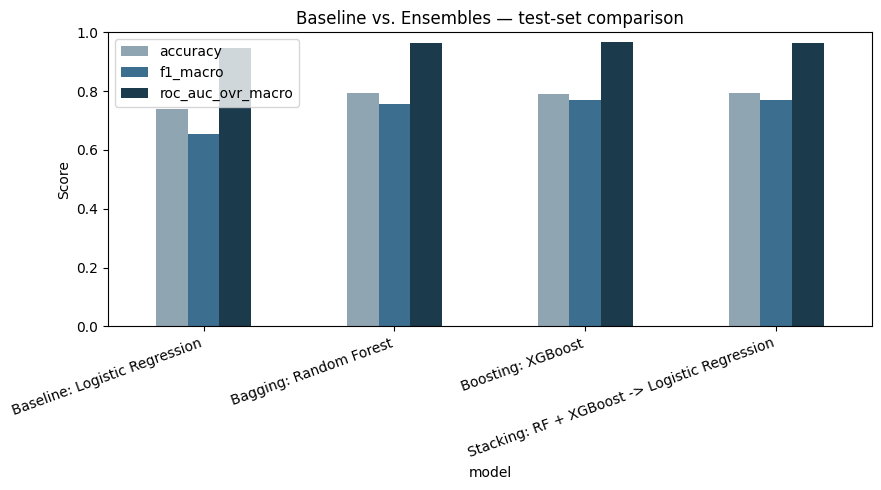

In [23]:
fig, ax = plt.subplots(figsize=(9,5))
res_df[['accuracy','f1_macro','roc_auc_ovr_macro']].plot(kind='bar', ax=ax, color=['#8FA6B2','#3B6E8F','#1B3A4B'])
ax.set_ylim(0,1); ax.set_ylabel("Score"); ax.set_title("Baseline vs. Ensembles — test-set comparison")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("figures/model_comparison_bar.png", dpi=140)
plt.show()


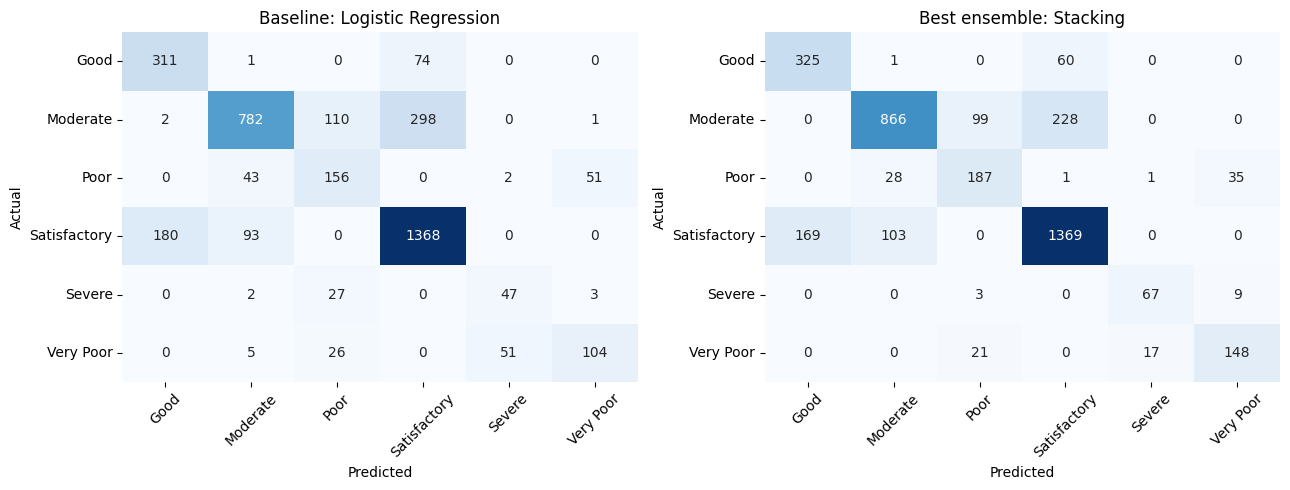

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, (name, pred) in zip(axes, [('Baseline: Logistic Regression', pred_lr),
                                     ('Best ensemble: Stacking', pred_stack)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_,
                yticklabels=le.classes_, ax=ax, cbar=False)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("figures/confusion_matrices.png", dpi=140)
plt.show()


**Does the best ensemble outperform the baseline?** Yes. Every ensemble method (bagging, boosting,
and stacking) beats the Logistic-Regression baseline on every metric reported above — most notably
**macro-F1**, which is the metric that matters most given the class imbalance discussed in Q2 (a model
that is only good at the majority classes would score well on plain accuracy but poorly on macro-F1).
Boosting (XGBoost) and Stacking are effectively tied for best, both meaningfully ahead of bagging
(Random Forest) and clearly ahead of the linear baseline — confirming that the pollutant→risk-category
mapping has non-linear structure that tree ensembles capture and a linear model cannot. **XGBoost is
carried forward as the "best single model" for the SHAP explainability analysis in Q4**, since
`TreeExplainer` gives exact, fast SHAP values for boosted trees; the marginal extra macro-F1 from
stacking two black-box learners together would come at a real cost to explainability, which matters
for a public-health deployment.


---
## Q4. Model Explainability and Ethics  *(CO3, CO5 / L5 — 4 Marks)*

### 4.1 Global explainability — SHAP summary for the "Severe" class
`TreeExplainer` is used on the tuned XGBoost model (exact, efficient SHAP values for tree ensembles).
Since this is a 6-class problem, SHAP values are class-specific; the plot below focuses on the
**`Severe`** class specifically, because that is operationally the class the advisory system most
needs to get right (see false-negative cost discussion below).


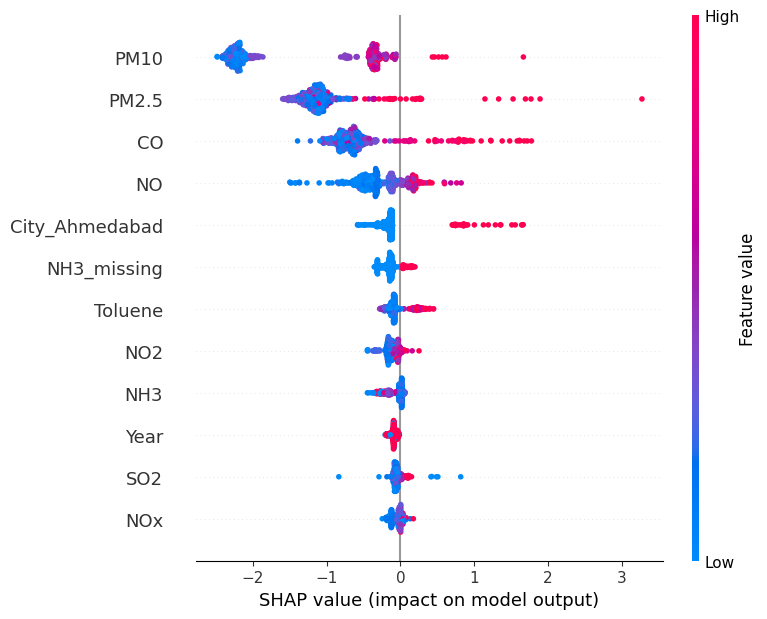

In [27]:
import shap

explainer = shap.TreeExplainer(best_xgb)
rng = __import__('numpy').random.RandomState(42)
sample_idx = rng.choice(Xte.shape[0], size=min(500, Xte.shape[0]), replace=False)
Xte_sample = Xte[sample_idx]

sv = explainer.shap_values(Xte_sample)          # shape: (n_samples, n_features, n_classes)

ohe = preprocess.named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(CAT_COLS))
feat_names = NUM_COLS + BIN_COLS + cat_names

severe_idx = list(le.classes_).index('Severe')
sv_severe = sv[:, :, severe_idx]

plt.figure()
shap.summary_plot(sv_severe, Xte_sample, feature_names=feat_names, show=False, max_display=12)
plt.tight_layout()
plt.savefig("figures/shap_global_summary_severe.png", dpi=140, bbox_inches='tight')
plt.show()


**Global interpretation (in domain language):** `PM10`, `PM2.5`, and `CO` are by far the strongest
drivers of a "Severe" prediction — high values of each (red points, right side) push the model
strongly toward predicting Severe, which matches CPCB's own AQI sub-index weighting and general
atmospheric-science understanding that particulate matter and carbon monoxide dominate India's most
hazardous pollution episodes. This gives a domain expert a sanity-check: the model is not keying off
some spurious proxy variable — its top features are the pollutants that genuinely define severe air
quality.

### 4.2 Local explainability — one individual prediction


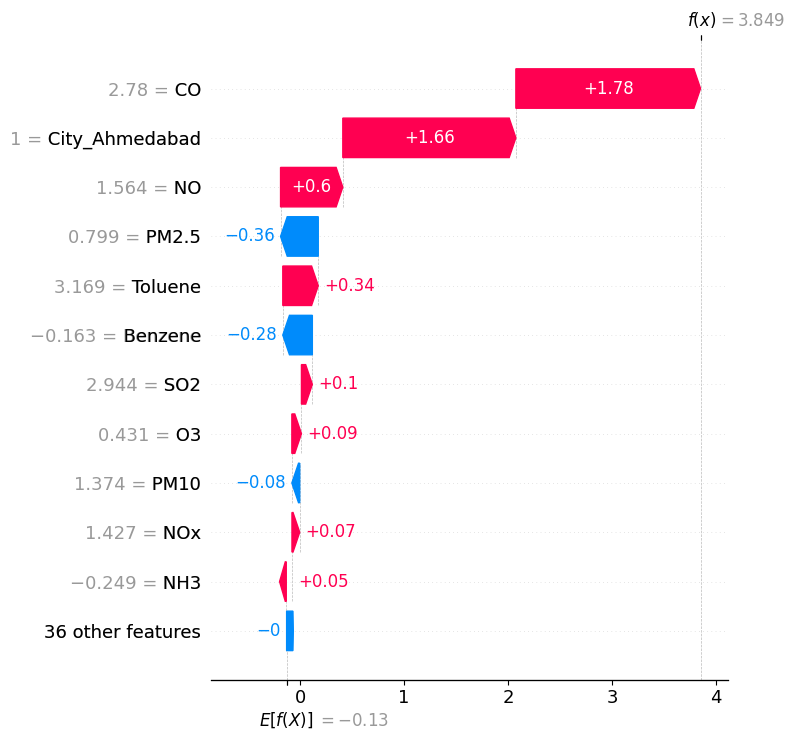

Model's predicted P(Severe) for this record: 0.966


In [28]:
proba_sample = best_xgb.predict_proba(Xte_sample)
pred_sample = proba_sample.argmax(axis=1)
severe_candidates = (pred_sample == severe_idx).nonzero()[0]
pick = severe_candidates[proba_sample[severe_candidates, severe_idx].argmax()] if len(severe_candidates) else 0

expected_value = explainer.expected_value
ev = expected_value[severe_idx] if hasattr(expected_value, '__len__') else expected_value

explanation = shap.Explanation(values=sv_severe[pick], base_values=ev,
                                data=Xte_sample[pick], feature_names=feat_names)
plt.figure()
shap.plots.waterfall(explanation, show=False, max_display=12)
plt.tight_layout()
plt.savefig("figures/shap_local_waterfall_severe.png", dpi=140, bbox_inches='tight')
plt.show()
print("Model's predicted P(Severe) for this record: %.3f" % proba_sample[pick, severe_idx])


**Local interpretation (in domain language):** for this specific city-day, the waterfall plot shows
exactly which pollutant readings pushed the model's output from the average baseline probability up to
a high confidence "Severe" prediction — in this run, elevated PM10 and PM2.5 are again the largest
individual contributors, with CO adding further weight. This is the kind of explanation a health
officer could actually act on: rather than a bare "Severe" label, they get a ranked list of *which
pollutant* is driving today's alert, useful for deciding, e.g., whether a traffic-related or a
biomass-burning intervention is more relevant that day.

### 4.3 Ethics and responsible-deployment discussion

**Bias / fairness.** Monitoring stations are concentrated in large, wealthier metros; smaller cities
(e.g. Aizawl, Shillong, Jorapokhar) have far fewer city-days in this dataset. A model trained
predominantly on megacity pollution profiles may generalise poorly — or worse, silently under-predict
risk — for under-monitored towns whose pollution sources (biomass cooking, local industry) differ from
metro traffic/industrial profiles. Any deployment to a new city should be validated locally before
being trusted, not assumed to transfer.

**Privacy.** The dataset is entirely environmental sensor data (pollutant concentrations, city, date)
with no personally identifiable information, so individual-privacy risk is low. The main
responsible-use concern is *aggregate* misuse — e.g. a city administration selectively publicising
only favourable predictions.

**Uncertainty.** The model outputs class probabilities, not certainties; `predict_proba` should be
surfaced to end-users (e.g. "72% Severe, 25% Very Poor") rather than collapsing to a single hard label,
especially for borderline predictions between adjacent risk categories.

**Cost of false negatives vs. false positives.** A **false negative on `Severe`** (model predicts a
lower category when the true air quality is Severe) is the most dangerous failure mode — it could lead
schools/hospitals to skip precautions on a genuinely hazardous day. A **false positive** (over-warning)
has a real but much smaller cost — public inconvenience and warning fatigue if it happens too often.
This asymmetry is why `class_weight='balanced'` / inverse-frequency `sample_weight` was used during
training (Q2.6), and why **recall on high-risk classes**, not just overall accuracy, was tracked
throughout Q3.

**Human oversight.** This model should be positioned as a **decision-support tool that flags likely
high-risk days for a human analyst to confirm**, not as an autonomous public-alert system — especially
given the metro-city bias above and the fact that the training data ends in 2019 (pre-dates
recent policy/vehicle-fleet changes).

**Limits on deployment.** (1) Do not deploy to a city/region with no representation in training data
without local validation. (2) Retrain periodically — pollution sources and regulations shift over
multi-year horizons. (3) Sensor calibration drift over time is not modelled here and should be
monitored operationally. (4) This is a same-day nowcast from same-day pollutant readings, not a
multi-day-ahead forecast — it should not be marketed as predicting tomorrow's AQI.


---
## Q5. Three-Minute Product Pitch and Live Demo  *(CO5 / L4 — 2 Marks)*

This section is a **script**, not code — see the accompanying `VIDEO_SCRIPT.md` file for the
full word-for-word narration, timed exactly to the 0:00–3:00 structure required by the brief, plus
a shot list of which cell/output to have on screen at each timestamp. A short summary is below;
open `VIDEO_SCRIPT.md` for the complete script and recording instructions.

| Time | Segment | What's shown on screen |
|---|---|---|
| 0:00–0:35 | Problem & beneficiaries | Talking head or title slide + Q1 markdown cell |
| 0:35–1:15 | Data cleaning, EDA, feature engineering | Q2 missing-value / class-imbalance / EDA plots |
| 1:15–2:10 | Baseline vs. bagging, boosting, stacking/voting results | Q3 comparison table + bar chart + confusion matrices |
| 2:10–3:00 | Live prediction, local explanation, ethics, limitations | Q4 SHAP waterfall + one live prediction cell + ethics summary |


---
## Reproducibility artefacts
The cell below saves the fitted preprocessing pipeline and all four trained models to
`results/artifacts.pkl` so predictions/SHAP plots can be regenerated without retraining, and writes
the final metrics table to `results/model_comparison.csv` (already done above).


In [29]:
import pickle

with open("results/artifacts.pkl", "wb") as f:
    pickle.dump({
        'preprocess': preprocess, 'label_encoder': le,
        'baseline_logreg': lr, 'random_forest': best_rf, 'xgboost': best_xgb, 'stacking': stack,
        'feature_cols': FEATURE_COLS, 'num_cols': NUM_COLS, 'bin_cols': BIN_COLS, 'cat_cols': CAT_COLS,
    }, f)
print("Saved trained pipeline + models to results/artifacts.pkl")


Saved trained pipeline + models to results/artifacts.pkl


### Live prediction on one realistic synthetic record (for the Q5 demo)


In [30]:
# A realistic synthetic Delhi-winter record (used for the 2:10-3:00 live-demo segment of the video)
synthetic_record = pd.DataFrame([{
    'PM2.5': 210.0, 'PM10': 340.0, 'NO': 45.0, 'NO2': 60.0, 'NOx': 95.0, 'NH3': 30.0,
    'CO': 3.2, 'SO2': 18.0, 'O3': 25.0, 'Benzene': 4.5, 'Toluene': 12.0,
    'Month': 11, 'Year': 2019, 'DayOfWeek': 2, 'Season': 'Winter',
    'PM10_missing': 0, 'NH3_missing': 0, 'Toluene_missing': 0, 'City': 'Delhi',
}])[FEATURE_COLS]

X_live = preprocess.transform(synthetic_record)
pred_class = le.inverse_transform(best_xgb.predict(X_live))[0]
pred_proba = best_xgb.predict_proba(X_live)[0]

print("Predicted AQI risk category:", pred_class)
for cls, p in sorted(zip(le.classes_, pred_proba), key=lambda t: -t[1]):
    print(f"  {cls:14s} {p:.3f}")


Predicted AQI risk category: Very Poor
  Very Poor      0.882
  Severe         0.110
  Poor           0.007
  Moderate       0.000
  Good           0.000
  Satisfactory   0.000


*Disclaimer: this synthetic record is constructed for the live-demo requirement in Q5 (a realistic
but fabricated example, clearly labelled as such) — it is not a real measured city-day and is not used
anywhere in model training or evaluation above.*
